### Conditional workflow 

customer review -> find sentiment -> check sentiment (either positive or negative) -> if negative -> run diagnosis -> apologies message
                                  -> if positive -> positive message

In [1]:
from langgraph.graph import StateGraph,START,END 
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="Sentiment of the review")    

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX","Performance","Bug","Support","Other"] = Field(description="The category of the issue mentioned in the review")
    tone: Literal["angry","frustrated","disappointed","calm"] = Field(description="The tone of the review")

In [5]:
structured_output = model.with_structured_output(SentimentSchema)
structured_diagnosis_output = model.with_structured_output(DiagnosisSchema)

In [7]:
class ReviewState(TypedDict):
    review: str 
    sentiment: str 
    diagonisis: dict 
    response: str 

In [8]:
def find_sentiment(state: ReviewState):
    prompt = f"Find the sentiment of the following statement - \n\n {state['review']}"
    result = structured_output.invoke(prompt)
    return {'sentiment': result.sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response","run_diagnosis"]:
    if state['sentiment'] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

def positive_response(state: ReviewState):
    prompt = f"Write a warm Thank you message in response to this feedback \n\n {state['review']}"
    response = model.invoke(prompt).content    
    return {'response':response}

def run_diagnosis(state: ReviewState):
    prompt = f"Diagnose the negative review: \n\n {state['review']} \n Return issue_type and tone"
    response = structured_diagnosis_output.invoke(prompt)
    return {'diagonisis': response.model_dump()} # model_dump() will dump the pydantic object into dict 

def negative_response(state: ReviewState):
    diagnosis = state['diagonisis']
    prompt = f"The user had a  issue type:{diagnosis['issue_type']} and a tone of the review is: {diagnosis['tone']}. Write a polite resolution message"
    response = model.invoke(prompt).content
    return {'response': response}


In [9]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)
graph.add_node("run_diagnosis",run_diagnosis)

graph.add_edge(START,'find_sentiment')
# conditional edges
graph.add_conditional_edges('find_sentiment',check_sentiment)

graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow = graph.compile()

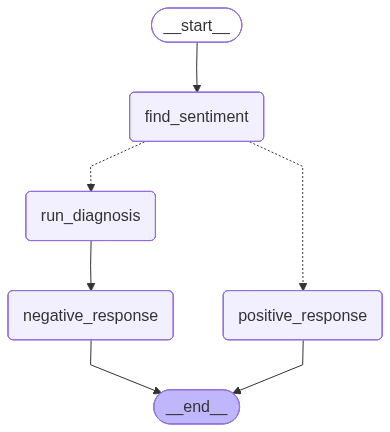

In [10]:
workflow

In [11]:
initial_flow = {
    'review': 'The product is really really bad'
}

In [12]:
workflow.invoke(initial_flow)

{'review': 'The product is really really bad',
 'sentiment': 'negative',
 'diagonisis': {'issue_type': 'Other', 'tone': 'angry'},
 'response': "Subject: We're Here to Help!\n\nDear [User's Name],\n\nThank you for reaching out to us and sharing your concerns. I sincerely apologize for the frustration you’ve experienced. Your feedback is important to us, and I want to assure you that we take your issue seriously.\n\nTo help us resolve this matter as quickly as possible, could you please provide more details about the specific problem you encountered? This will allow us to address your concerns effectively and improve our services.\n\nThank you for your patience and understanding. We look forward to assisting you further and resolving this issue to your satisfaction.\n\nBest regards,\n\n[Your Name]  \n[Your Position]  \n[Your Contact Information]  \n[Company Name]  "}